   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

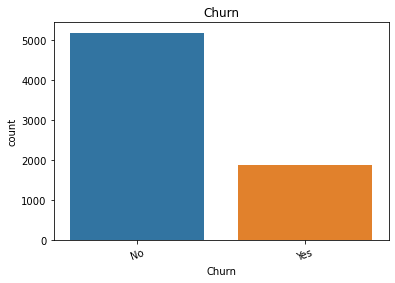

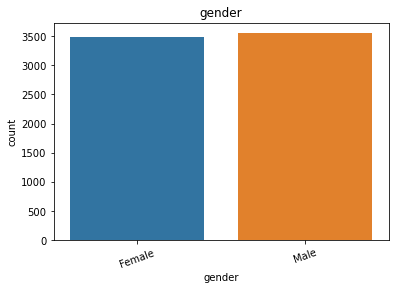

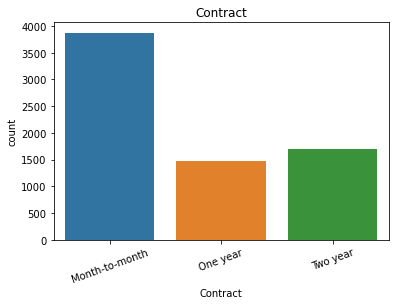

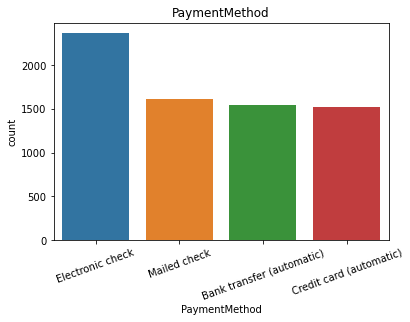

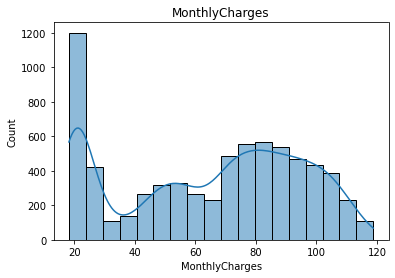

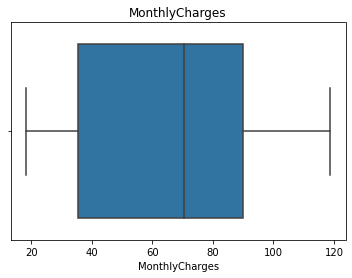

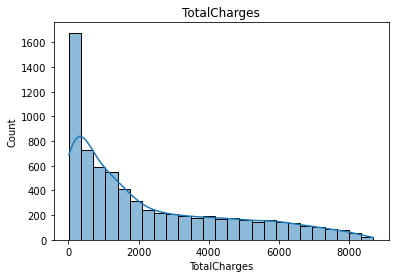

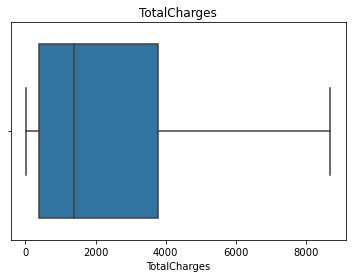

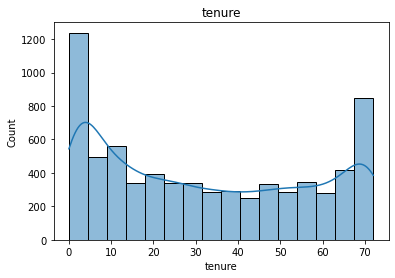

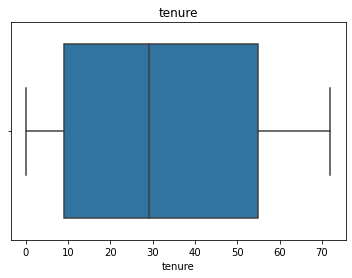

MonthlyCharges Outliers: 0
TotalCharges Outliers: 0
tenure Outliers: 0


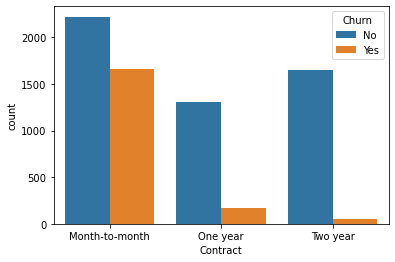

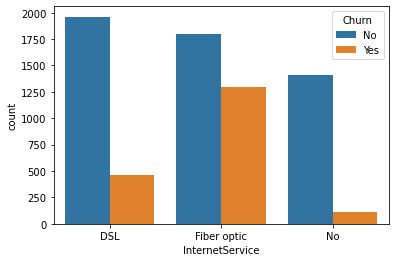

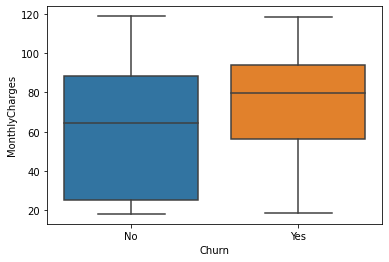

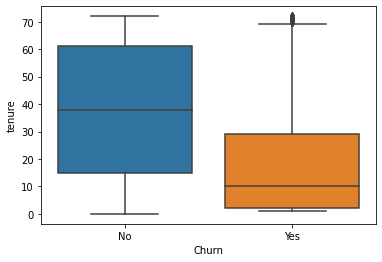

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48
Electronic check             1071
Mailed check                  308
Bank transfer (automatic)     258
Credit card (automatic)       232
Name: PaymentMethod, dtype: int64
Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64
Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64
Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113
(5634, 30)
(1409, 30)
CustomerChurn_Preprocessed.csv saved successfully.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv(r"C:\Users\HDC0422044\Downloads\archive (9)\Telco-Customer-Churn.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

df.drop_duplicates(inplace=True)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

print(df.describe())

for col in ["Churn", "gender", "Contract", "PaymentMethod"]:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.xticks(rotation=20)
    plt.show()

for col in ["MonthlyCharges", "TotalCharges", "tenure"]:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

for col in ["MonthlyCharges", "TotalCharges", "tenure"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(col, "Outliers:", len(outliers))

sns.countplot(x="Contract", hue="Churn", data=df)
plt.show()

sns.countplot(x="InternetService", hue="Churn", data=df)
plt.show()

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

print(pd.crosstab(df["Contract"], df["Churn"]))

print(df[df["Churn"] == "Yes"]["PaymentMethod"].value_counts())

print(df.groupby("Churn")["tenure"].mean())

print(df.groupby("Churn")["MonthlyCharges"].mean())

print(pd.crosstab(df["InternetService"], df["Churn"]))

df.drop("customerID", axis=1, inplace=True)

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Churn_Yes", axis=1)
y = df["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

df.to_csv("CustomerChurn_Preprocessed.csv", index=False)

print("CustomerChurn_Preprocessed.csv saved successfully.")